In [1]:
import numpy as np
from torch import tensor
from torch.nn.functional import normalize
from minivec2vec import train, train_test_split

ds1 = 'nq'
model1 = 'e5'
model2 = 'gte'

ds1_model1, ds1_model2 = np.load(f'embeddings/{ds1}/{model1}.npy'), np.load(f'embeddings/{ds1}/{model2}.npy')
ds1_model1, ds1_model2 = tensor(ds1_model1), tensor(ds1_model2)

X_train, Y_train, X_eval, Y_eval = train_test_split(
    ds1_model1, ds1_model2,
    num_train_samples=1_000,
    num_test_samples=64_000
)

X_train, Y_train, X_eval, Y_eval = normalize(X_train, dim=-1), normalize(Y_train, dim=-1), X_eval, Y_eval

# W = train(X_train, Y_train)

In [2]:
import torch

W = torch.load('weights/nq/e5_to_gte.pt')

In [3]:
import wandb
import torch
import torch.nn.functional as F
import numpy as np
from mini.topology import compute_wasserstein_distance, compute_cca_metrics, compute_svcca
from utils.eval_utils import compute_topk_accuracy_and_avg_rank

run = wandb.init(project="vec2vec_translator", name="linear_translator_eval")

def evaluate_metrics(X, Y, prefix="val"):
    res = {}
    
    # Ensure on same device
    if X.device != Y.device:
        X = X.to(Y.device)
        
    # --- Standard & Retrieval Metrics (Requires same dimension) ---
    if X.shape[1] == Y.shape[1]:

        # MSE
        res[f"{prefix}/{model1}_{model2}_mse"] = F.mse_loss(Y, X).item()

        # Cosine Similarity
        res[f"{prefix}/{model1}_{model2}_cos"] = F.cosine_similarity(Y, X).mean().item()
        res[f"{prefix}/{model2}_{model1}_cos"] = F.cosine_similarity(X, Y).mean().item()

        # Std
        res[f"{prefix}/{model1}_{model2}_std"] = X.std(dim=0).mean().item()

        # VSP (Visual Semantic Pose)
        n_vsp = min(1000, len(X))
        indices = torch.randperm(len(X))[:n_vsp]
        X_sub = F.normalize(X[indices], dim=1)
        Y_sub = F.normalize(Y[indices], dim=1)
        
        in_distances = 1 - (Y_sub @ Y_sub.T)
        out_distances = 1 - (X_sub @ X_sub.T)
        res[f"{prefix}/{model1}_{model2}_vsp"] = (in_distances - out_distances).abs().mean().item()

        # Retrieval Metrics
        sims = X @ Y.T
        sorted_indices = torch.argsort(sims, dim=1, descending=True)
        ground_truth = torch.eye(len(X), device=X.device)

        for k in [1, 16]:
            acc, avg_rank = compute_topk_accuracy_and_avg_rank(sorted_indices, ground_truth, k=k)
            res[f"{prefix}/{model1}_{model2}_top_{k}_acc"] = acc
            res[f"{prefix}/{model1}_{model2}_avg_rank"] = avg_rank
    else:
        print(f"[{prefix}] Skipping Standard & Retrieval metrics due to dimension mismatch ({X.shape[1]} vs {Y.shape[1]})")

    X_cpu = X.cpu()
    Y_cpu = Y.cpu()

    topo_metrics = compute_cca_metrics(X_cpu, Y_cpu)
    res[f"{prefix}/topo_{model1}_to_{model2}_mean_cca"] = topo_metrics['mean_cca']
    res[f"{prefix}/topo_{model1}_to_{model2}_pwcca"] = topo_metrics['pwcca']

    svcca_corrs = compute_svcca(X_cpu, Y_cpu)
    res[f"{prefix}/topo_{model1}_to_{model2}_mean_svcca"] = float(np.mean(svcca_corrs))

    wasserstein_dist = compute_wasserstein_distance(X_cpu, Y_cpu, dim=1, n_samples=1000)
    if wasserstein_dist is not None:
        res[f"{prefix}/topo_{model1}_to_{model2}_wasserstein_h1"] = wasserstein_dist
        
    return res

pre_metrics = evaluate_metrics(X_eval, Y_eval)
wandb.log(pre_metrics)

if W.device != X_eval.device:
    W = W.to(X_eval.device)
    
X_trans = X_eval @ W
post_metrics = evaluate_metrics(X_trans, Y_eval)
wandb.log(post_metrics)

run.finish()

wandb: Currently logged in as: cole-donat (cole-d0) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


val/e5_gte_avg_rank,█▁
val/e5_gte_cos,▁█
val/e5_gte_mse,█▁
val/e5_gte_std,█▁
val/e5_gte_top_16_acc,▁▁
val/e5_gte_top_1_acc,▁█
val/e5_gte_vsp,█▁
val/gte_e5_cos,▁█
val/topo_e5_to_gte_mean_cca,█▁
val/topo_e5_to_gte_mean_svcca,▁█
+2,...


In [4]:
pre_metrics, post_metrics

({'val/e5_gte_mse': 0.0008511016494594514,
  'val/e5_gte_cos': 0.6731770038604736,
  'val/gte_e5_cos': 0.6731770038604736,
  'val/e5_gte_std': 0.02025200054049492,
  'val/e5_gte_vsp': 0.04065512865781784,
  'val/e5_gte_top_1_acc': 0.9979375,
  'val/e5_gte_avg_rank': 1.10215625,
  'val/e5_gte_top_16_acc': 0.999953125,
  'val/topo_e5_to_gte_mean_cca': 0.47713602,
  'val/topo_e5_to_gte_pwcca': 0.61946595,
  'val/topo_e5_to_gte_mean_svcca': 0.6134078502655029,
  'val/topo_e5_to_gte_wasserstein_h1': 48.01152474083463},
 {'val/e5_gte_mse': 0.00020959031826350838,
  'val/e5_gte_cos': 0.9181314706802368,
  'val/gte_e5_cos': 0.9181314706802368,
  'val/e5_gte_std': 0.018984545022249222,
  'val/e5_gte_vsp': 0.019956419244408607,
  'val/e5_gte_top_1_acc': 0.998375,
  'val/e5_gte_avg_rank': 1.00590625,
  'val/e5_gte_top_16_acc': 0.999953125,
  'val/topo_e5_to_gte_mean_cca': 0.47710228,
  'val/topo_e5_to_gte_pwcca': 0.63877314,
  'val/topo_e5_to_gte_mean_svcca': 0.62615966796875,
  'val/topo_e5_to_g

--- Hubness Evaluation (k=10) ---
Skewness (S-measure): 4.6341
Max Occurrences (Top Hub): 248 (Should be close to k)
Orphan Percentage: 0.00%


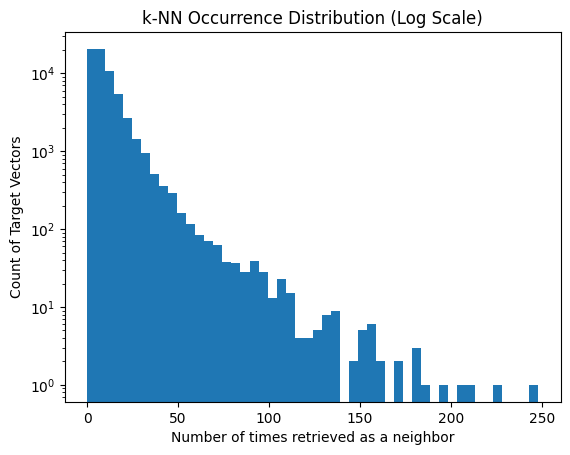

In [5]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from scipy.stats import skew
import matplotlib.pyplot as plt

def evaluate_hubness(X_mapped, Y_target, k=10):
    """
    X_mapped: Source embeddings after applying your linear matrix W (N x D)
    Y_target: The actual Target embeddings (M x D)
    k: Number of neighbors to check
    """
    
    # 1. Build a Nearest Neighbor index on the TARGET space
    nbrs = NearestNeighbors(n_neighbors=k, metric='cosine', algorithm='brute')
    nbrs.fit(Y_target)
    
    # 2. Find the k-nearest neighbors in Y for every point in X_mapped
    # indices shape: (N_samples, k)
    distances, indices = nbrs.kneighbors(X_mapped)
    
    # 3. Flatten the indices array to get a massive list of all retrieved IDs
    all_retrieved_indices = indices.flatten()
    
    # 4. Count occurrences of each Target index (0 to M-1)
    # bincount is fast; requires integer inputs (indices)
    # minlength ensures we count targets that were NEVER retrieved (orphans)
    occurrence_counts = np.bincount(all_retrieved_indices, minlength=Y_target.shape[0])
    
    # SKEWNESS: The standard metric for hubness
    # > 0 means tail to the right. High positive values = High Hubness.
    hubness_skew = skew(occurrence_counts)
    
    # MAX HUB: The single most popular vector
    max_occurrence = np.max(occurrence_counts)
    
    # ANTI-HUBS: Percentage of target vectors that were never retrieved
    # If this is high (e.g., >50%), your map is collapsing onto a small region.
    orphans = np.sum(occurrence_counts == 0) / len(occurrence_counts)
    
    print(f"--- Hubness Evaluation (k={k}) ---")
    print(f"Skewness (S-measure): {hubness_skew:.4f}")
    print(f"Max Occurrences (Top Hub): {max_occurrence} (Should be close to k)")
    print(f"Orphan Percentage: {orphans:.2%}")
    
    return occurrence_counts

# Usage
counts = evaluate_hubness(X_eval @ W, Y_eval, k=10)

plt.hist(counts, bins=50, log=True)
plt.title("k-NN Occurrence Distribution (Log Scale)")
plt.xlabel("Number of times retrieved as a neighbor")
plt.ylabel("Count of Target Vectors")
plt.show()

In [6]:
import wandb
import numpy as np

# Initialize run (update project/name as needed)
run = wandb.init(project="unsupervised_disc", name="hubness_chart_well_aligned")

# Ensure counts is a 1-D numpy array
counts_arr = np.asarray(counts)
# Build a wandb Table with a single column called 'scores'; each row must be an iterable
table = wandb.Table(data=[[int(c)] for c in counts_arr], columns=["scores"])

# Plot a histogram from the table using wandb.plot.histogram
wandb.log({
    "kNN_occurrence_histogram": wandb.plot.histogram(table, "scores", title="k-NN Occurrence Distribution")
})

print(table)
run.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


In [20]:
run.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.
